<a href="https://colab.research.google.com/github/mahamoorthi22007/AI-Internship/blob/main/Logistic_Regression_on_Divorce_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/divorce_df.csv')

In [ ]:
df.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,1,5.536016,3,...,0,0,0,8.428183,5,Love,1,0,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,1,5.810172,3,...,0,1,0,5.297221,1,Love,1,0,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,0,6.088146,3,...,0,0,0,5.887066,1,Arranged,1,0,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,1,6.212046,3,...,0,0,0,5.263555,5,Love,1,0,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,1,4.826262,1,...,0,0,1,5.771259,4,Love,1,0,10.000000,1


In [ ]:
df.tail()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
4995,27,1,3,Master,Full-time,67410,Same Religion,1,7.406795,1,...,0,0,0,4.071359,4,Arranged,1,0,6.333963,0
4996,31,21,2,Bachelor,Homemaker,88995,Same Religion,1,3.971897,2,...,0,1,1,3.064645,3,Love,1,0,3.279566,0
4997,43,13,2,Bachelor,Homemaker,93184,Same Religion,0,10.000000,4,...,1,0,0,7.728128,3,Other,0,0,4.002068,1
4998,32,1,2,Master,Part-time,54132,Same Religion,1,3.382175,2,...,0,0,0,8.827352,3,Arranged,1,0,3.790967,0
4999,23,8,2,Bachelor,Full-time,38412,Different Religion,1,5.471466,2,...,0,0,0,4.609792,6,Love,1,0,5.163251,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_at_marriage            5000 non-null   int64  
 1   marriage_duration_years    5000 non-null   int64  
 2   num_children               5000 non-null   int64  
 3   education_level            5000 non-null   object 
 4   employment_status          5000 non-null   object 
 5   combined_income            5000 non-null   int64  
 6   religious_compatibility    5000 non-null   object 
 7   cultural_background_match  5000 non-null   int64  
 8   communication_score        5000 non-null   float64
 9   conflict_frequency         5000 non-null   int64  
 10  conflict_resolution_style  5000 non-null   object 
 11  financial_stress_level     5000 non-null   float64
 12  mental_health_issues       5000 non-null   int64  
 13  infidelity_occurred        5000 non-null   int64

In [ ]:
df.describe()

,age_at_marriage,marriage_duration_years,num_children,combined_income,cultural_background_match,communication_score,conflict_frequency,financial_stress_level,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,27.583600,9.171000,1.552800,60220.078400,0.755400,6.040507,2.008000,5.071450,0.203800,0.149000,0.240400,5.966853,2.972600,0.592200,0.050400,6.030525,0.398200
std,4.855978,8.848266,1.247527,19662.080982,0.429893,1.963349,1.412351,2.326322,0.402862,0.356124,0.427369,1.965504,1.711735,0.491475,0.218791,1.932922,0.489576
min,18.000000,1.000000,0.000000,10000.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,24.000000,2.000000,1.000000,46666.000000,1.000000,4.661929,1.000000,3.365562,0.000000,0.000000,0.000000,4.597007,2.000000,0.000000,0.000000,4.702663,0.000000
50%,28.000000,6.000000,1.000000,60196.000000,1.000000,6.058246,2.000000,5.062464,0.000000,0.000000,0.000000,6.010716,3.000000,1.000000,0.000000,6.034343,0.000000
75%,31.000000,13.000000,2.000000,73666.500000,1.000000,7.426862,3.000000,6.717954,0.000000,0.000000,0.000000,7.328916,4.000000,1.000000,0.000000,7.372830,1.000000
max,45.000000,40.000000,6.000000,126909.000000,1.000000,10.000000,9.000000,10.000000,1.000000,1.000000,1.000000,10.000000,10.000000,1.000000,1.000000,10.000000,1.000000


In [ ]:
df.isnull().sum()

,0
age_at_marriage,0
marriage_duration_years,0
num_children,0
education_level,0
employment_status,0
combined_income,0
religious_compatibility,0
cultural_background_match,0
communication_score,0
conflict_frequency,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
l=LabelEncoder()

In [ ]:
column=['education_level','employment_status','religious_compatibility','conflict_resolution_style','marriage_type']

In [ ]:
for x in column:
  df[x]=l.fit_transform(df[x])

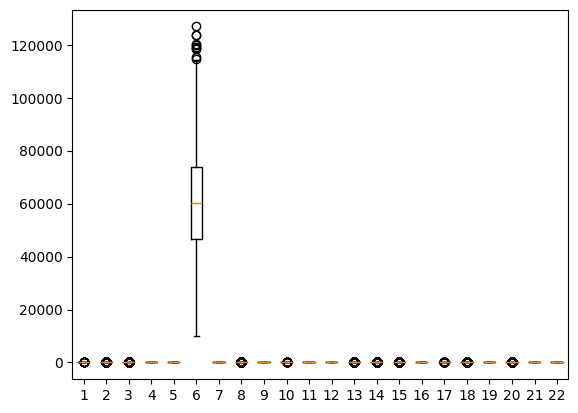

In [ ]:
plt.boxplot(df)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
s=StandardScaler()

In [ ]:
df['religious_compatibility']=s.fit_transform(df[['religious_compatibility']])

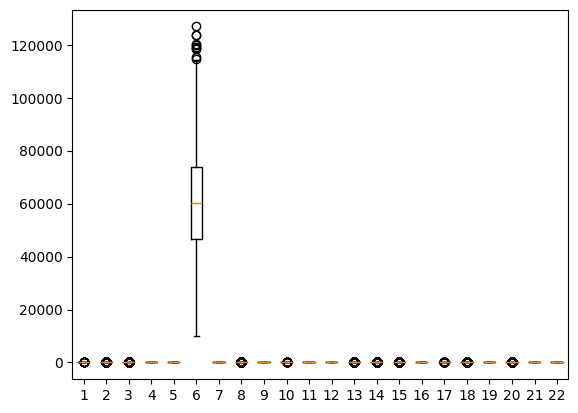

In [ ]:
plt.boxplot(df)
plt.show()

In [ ]:
x=df.drop('divorced',axis=1)

In [ ]:
y=df['divorced']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=LogisticRegression()

In [ ]:
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
a=accuracy_score(y_test,y_pred)

In [ ]:
a

0.612